In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'F:\AI\HDRP\HDRP\data\heart.csv')

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(918, 12)
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR          

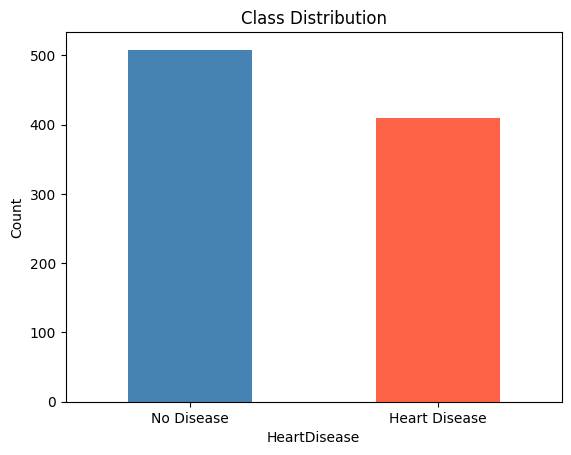

In [2]:
df['HeartDisease'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Class Distribution')
plt.xticks([0, 1], ['No Disease', 'Heart Disease'], rotation=0)
plt.ylabel('Count')
plt.show()

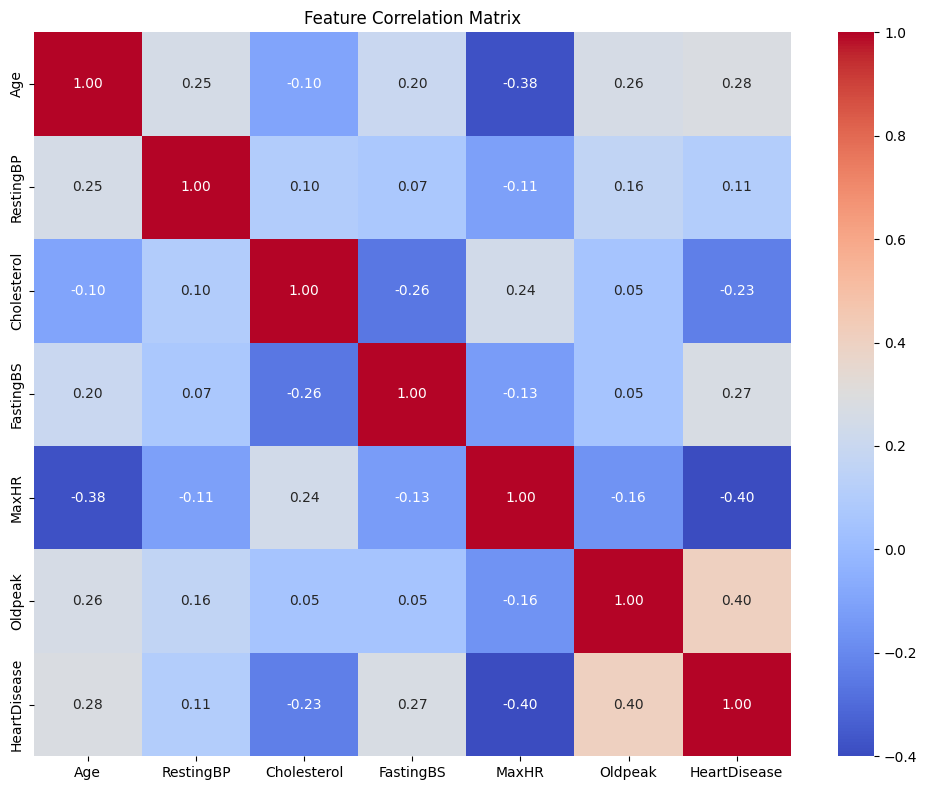

In [3]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

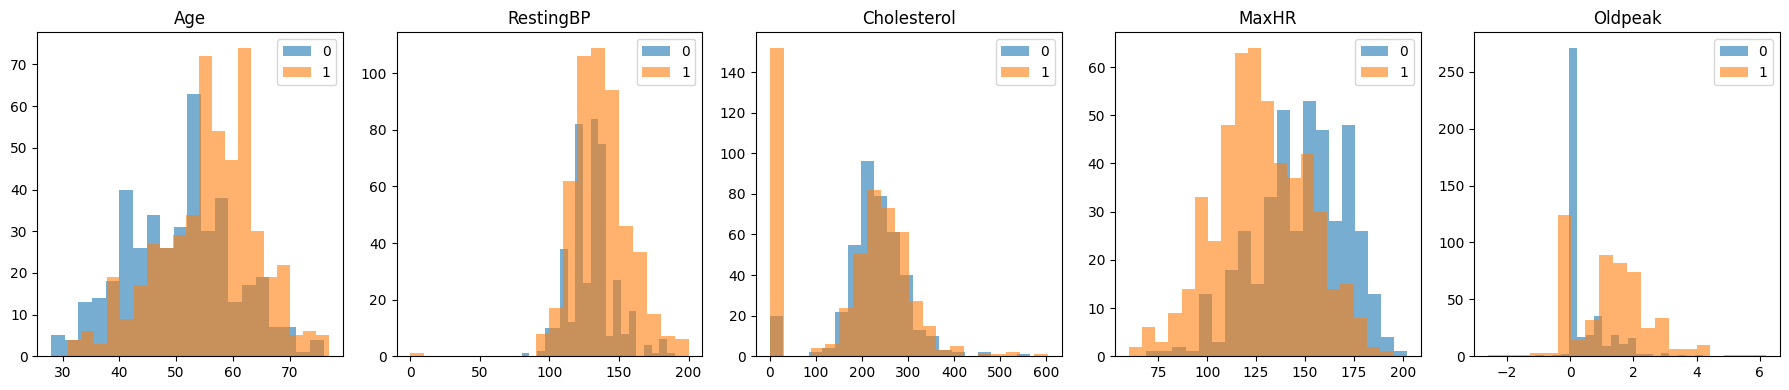

In [4]:
num_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_features):
    for label, grp in df.groupby('HeartDisease'):
        ax.hist(grp[col], alpha=0.6, label=str(label), bins=20)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

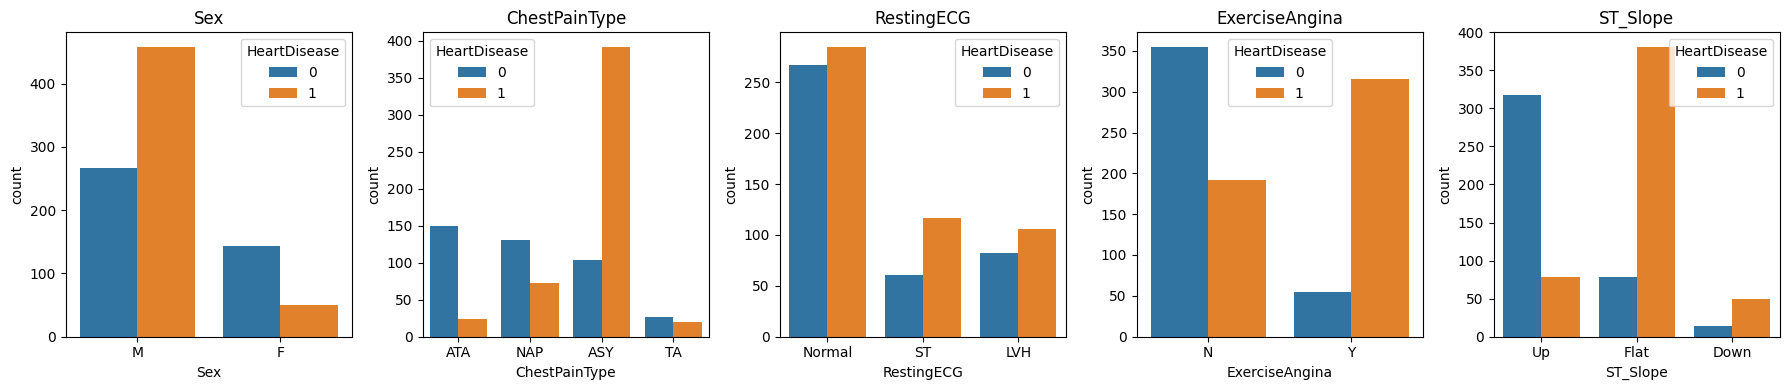

In [5]:
cat_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, cat_features):
    sns.countplot(data=df, x=col, hue='HeartDisease', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

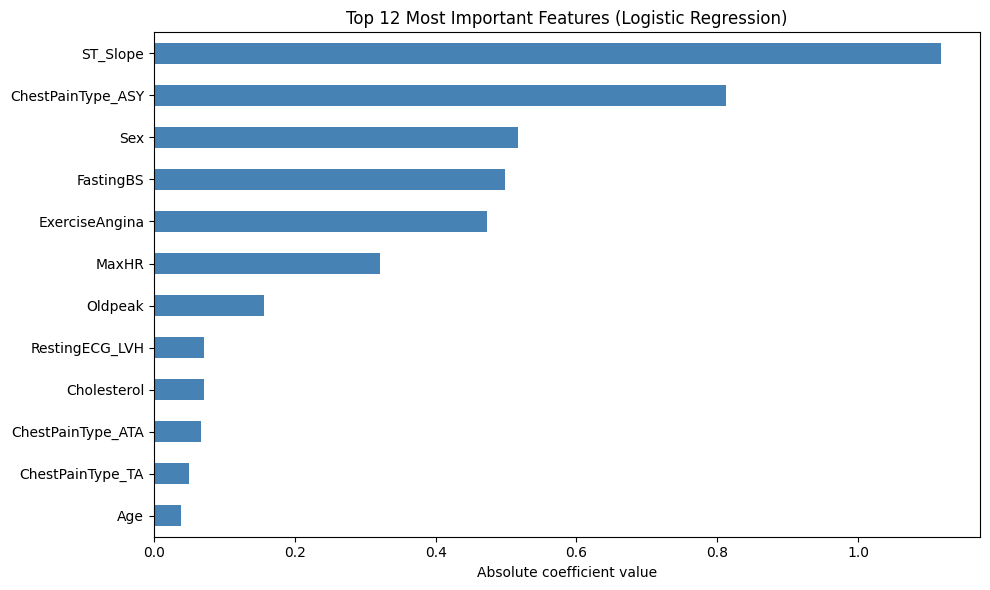

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load saved model and get feature names
lr_model = joblib.load(r'F:\AI\HDRP\HDRP\models\logistic_regression.pkl')
scaler = joblib.load(r'F:\AI\HDRP\HDRP\models\scaler.pkl')

# We need feature names - rerun preprocessing to get them
import sys
sys.path.append(r'F:\AI\HDRP\HDRP')
from src.preprocess import load_and_preprocess

X_train, X_test, y_train, y_test, scaler, feature_names = \
    load_and_preprocess(r'F:\AI\HDRP\HDRP\data\heart.csv')

# Plot feature importance
coef = lr_model.coef_[0]
importance = pd.Series(np.abs(coef), index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.head(12).plot(kind='barh', color='steelblue')
plt.xlabel('Absolute coefficient value')
plt.title('Top 12 Most Important Features (Logistic Regression)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


── Logistic Regression ──
               precision    recall  f1-score   support

   No Disease       0.88      0.82      0.85        82
Heart Disease       0.86      0.91      0.89       102

     accuracy                           0.87       184
    macro avg       0.87      0.86      0.87       184
 weighted avg       0.87      0.87      0.87       184

ROC-AUC: 0.9030


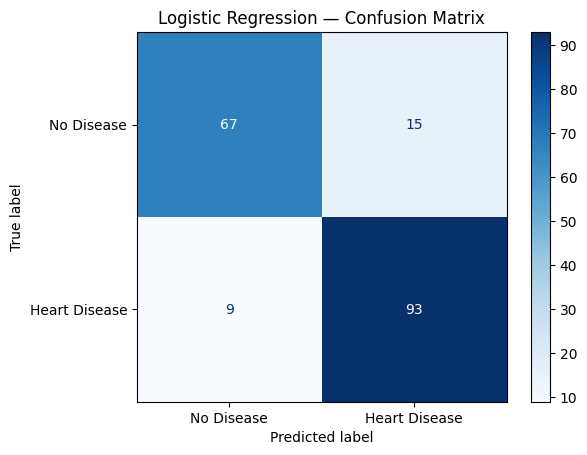

Default threshold (0.5):
Optimal threshold: 0.405
Precision at optimal: 0.857
Recall at optimal:    0.941
F1 at optimal:        0.897


In [3]:
from sklearn.metrics import precision_recall_curve
from src.evaluate import evaluate_model

# Get predictions
lr_proba, _ = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression')

# Find optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, lr_proba)
f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1s)
best_thresh = thresholds[best_idx]

print(f'Default threshold (0.5):')
print(f'Optimal threshold: {best_thresh:.3f}')
print(f'Precision at optimal: {precisions[best_idx]:.3f}')
print(f'Recall at optimal:    {recalls[best_idx]:.3f}')
print(f'F1 at optimal:        {f1s[best_idx]:.3f}')

In [4]:
# Feature engineering example
df2 = pd.read_csv(r'F:\AI\HDRP\HDRP\data\heart.csv')

df2['MaxHR_Age_Ratio'] = df2['MaxHR'] / df2['Age']
df2['High_Cholesterol'] = (df2['Cholesterol'] > 240).astype(int)
df2['Hypertension'] = (df2['RestingBP'] > 140).astype(int)

print('New features added:')
print(df2[['MaxHR_Age_Ratio', 'High_Cholesterol', 'Hypertension']].head(10))
print(f'\nHigh Cholesterol patients: {df2["High_Cholesterol"].sum()}')
print(f'Hypertension patients: {df2["Hypertension"].sum()}')

New features added:
   MaxHR_Age_Ratio  High_Cholesterol  Hypertension
0         4.300000                 1             0
1         3.183673                 0             1
2         2.648649                 1             0
3         2.250000                 0             0
4         2.259259                 0             1
5         4.358974                 1             0
6         3.777778                 0             0
7         2.629630                 0             0
8         3.513514                 0             0
9         2.500000                 1             0

High Cholesterol patients: 355
Hypertension patients: 220
